# Misspecified Symmetry Priors: 1D Sensitivity Analysis

This notebook extends the synthetic 1D conditional-expectation/cCDF experiment to analyze **symmetry-prior misspecification**. In particular, we study the cases of **incorrect** and **extrinsic** misspecification, following the taxonomy of [Wang et al. (2023)](https://proceedings.neurips.cc/paper_files/paper/2023/hash/7dc7793c89b93887e126a86f22ef63c6-Abstract-Conference.html).



1. **Extrinsic misspecification of $P_{\mathbf{x}}$ $\mathbb{G}$-invariance**:  
    This scenario arises when the assumption that the marginal distribution of $\mathbf{x}$ is $\mathbb{G}$-invariant is violated. Specifically, the support of the random variable in the training, validation, and test sets is not $\mathbb{G}$-invariant, so the empirical distribution of $\mathbf{x}$ is biased toward only a subset of the support of $P_{\mathbf{x}}$. We study this setting by training on a biased half-space ($\mathbf{x} > 0$) and evaluating performance both on the same biased support and on the full support ($\mathbf{x} > 0$ and $\mathbf{x} \in \mathbb{R}$).

    <div align="center">
      <img src="./plots/misspec_px_protocol.png" alt="Marginal coverage grid" width="80%" />
    </div>

    In this setting, assuming $\mathbb{G}$-invariance of $P_{\mathbf{x}}$ and using the eNCP model acts as a form of regularization, enabling out-of-distribution generalization without degrading performance on the biased support.

2. **Incorrect misspecification of $P_{\mathbf{y} \mid \mathbf{x}}$ $\mathbb{G}$-invariance**:  
    This scenario corresponds to violations of the assumption that the conditional distribution of $\mathbf{y}$ given $\mathbf{x}$ is $\mathbb{G}$-equivariant on a subset of the support of $\mathbf{x}$. We consider two types of incorrect misspecification:
    - **Unbiased incorrect misspecification**: Here, we progressively scale the heteroscedastic noise amplitude in the region $\mathbf{x} > 1$. This violates the $\mathbb{G}$-invariance of $P_{\mathbf{y} \mid \mathbf{x}}$ while preserving the $\mathbb{G}$-equivariance of the conditional expectation $\mathbb{E}[\mathbf{y} \mid \mathbf{x}]$.

    <div align="center">
      <img src="./plots/incorrect_conditional_protocol_C=2.png" width="48%" />
      <img src="./plots/incorrect_conditional_protocol_C=6.png" width="48%" />
    </div>

    - **Biased incorrect misspecification**: Here, we progressively introduce a linear bias in the region $\mathbf{x} > 1$. This violates both the $\mathbb{G}$-invariance of $P_{\mathbf{y} \mid \mathbf{x}}$ and the $\mathbb{G}$-equivariance of the conditional expectation $\mathbb{E}[\mathbf{y} \mid \mathbf{x}]$ on the subset $|\mathbf{x}| > 1$.

    <div align="center">
      <img src="./plots/incorrect_conditional_biased_protocol_b=0p2.png" width="48%" />
      <img src="./plots/incorrect_conditional_biased_protocol_b=0p75.png" width="48%" />
    </div>

We compare the performance of the NCP model and the eNCP model under these misspecification scenarios, quantifying the degradation of the eNCP model as the misspecification becomes more severe, and studying if **degradation occurs only on the subset of the support where the misspecification occurs** or also on the rest of the support.


### Imports and Setup

In [71]:
%load_ext autoreload
%autoreload 2

import os
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import escnn

from symm_learning.models import MLP, iMLP
from symm_rep_learn.inference import ENCPConditionalCDF, NCPConditionalCDF
from symm_rep_learn.models import ENCP
from symm_rep_learn.models.neural_conditional_probability.ncp import NCP
from symm_rep_learn.nn.layers import ResidualEncoder
from torch.utils.data import DataLoader, TensorDataset

# Paths
ROOT = pathlib.Path(os.getcwd())
WS_PATH = ROOT.parent.parent.parent
PLOT_PATH = ROOT / "plots"
PLOT_PATH.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = ROOT / "checkpoints"
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
METRICS_PATH = PLOT_PATH / "metrics"
METRICS_PATH.mkdir(parents=True, exist_ok=True)

# Imports from repository
sys.path.append(str(WS_PATH))

from paper.examples.utils import (
    dataframe_to_markdown,
    fit_or_load_ncp_like,
    make_condexp_1d_dataset,
    make_condexp_1d_dataset_incorrect_conditional,
    make_condexp_1d_dataset_incorrect_conditional_biased,
    make_positive_bias_train_val_split,
    plot_saved_training_curves_panel,
    split_standardize_tensors,
    split_x_side_masks,
    true_condexp_1d,
    true_condexp_1d_incorrect_conditional_biased,
)
from paper.examples.conditional_expectation_regression.plotting import (
    plot_expectations_with_quantiles,
    scatter_with_density,
)


SEED = 10
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
plt.style.use("seaborn-v0_8-notebook")
FIG_SIZE = (5.5, 3)

# Data sizes
N = 20_000
TRAIN_POS_RATIO = 0.85  # split ratio inside x>0 subset for train/val
EVAL_N = 50_000

# Training hyperparameters
EMBEDDING_DIM = 32
BATCH_SIZE = 2024
EPOCHS = 2500
CHECK_EVERY = 10
PATIENCE = 50
PLOT_FREQ = 100
NCP_LR = 2e-3

print(f"Device: {DEVICE}")
print(f"Workspace root: {WS_PATH}")
print(f"Experiment root: {ROOT}")

# Symmetry representations used for symmetry-aware standardization
G = escnn.group.CyclicGroup(2)
x_rep = G.irrep(1)
y_rep = G.trivial_representation


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda
Workspace root: /home/danfoa/Projects/symm_rep_learn
Experiment root: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis


# 1. Extrinsic Misspecification of Marginal $\mathbb{C}_2$-Invariance

<b>Extrinsic symmetry misspecification.</b>
Following the correct/incorrect/extrinsic symmetry misspecification taxonomy of [Wang et al. (2023)](https://proceedings.neurips.cc/paper_files/paper/2023/hash/7dc7793c89b93887e126a86f22ef63c6-Abstract-Conference.html), this experiment studies the <b>extrinsic</b> case, in which the the $\mathbb{G}$-invariance of the marginal distribution $P_{x}$ is violated in the empirical training/validation/test distributions. In this scenario, the conditional distribution $P_{Y|X}$ is assumed to comply with the $\mathbb{G}$-invariance prior.

We consider $\mathcal{X}\subset\mathbb{R}$ with reflection symmetry
$\mathbb{G}=\mathbb{C}_2=\{e,g_r\}$, where
$g_r\triangleright_{\mathcal{X}}x=-x$ and $g_r\triangleright_{\mathcal{Y}}y=y$.
Hence the conditional law $P_{Y \mid X}$ is $\mathbb{C}_2$-invariant.

In this scenario extrinsic misspecification implies that the training/validation/testing empirical samplings from $P_{x}$ are biased toward one coset/space (here, mostly $x>0$). Hence, as depicted below, although the conditional distribution remains invariant, the NNs will be trained only on one side of the support, and never see in practice the symetry transformed conditionings. 

<div align="center">
  <img src="./plots/misspec_px_protocol.png" width="70%" />
</div>

<b>Summary conclusions.</b>

As depicted below, enforcing the NN embedding of $\mathcal{X}$ to be $\mathbb{C}_2$-equivariant does not impact the performance of the model on the nominal support ($x>0$). However, it endows the model with prediction capabilities in the out-of-distribution (o.o.d) region ($x<0$). Hence, the symmetry priors act as a regularization of the model improving generalization. In practice, as equivariance constraints reduce the number of trainable parameters in the NN, its expected for eNCP to underperform NCP on the nominal support, since NCP uses more parameters to fit support of the training distribution. However, in this experiment we dont see such a degradation.
<div align="center">
  <img src="./plots/misspec_px_quantile_predictions.png" width="82%" />
</div>

As depicted below, the side-wise decomposition (log-scale) confirms that the equivariant prior helps on OOD support without materially hurting performance in the "nominal" support ($x>0$).

<div align="center">
  <img src="./plots/misspec_px_sidewise_error_decomposition.png" width="82%" />
</div>

<b>References:</b>

Wang, D., Zhu, X., Park, J. Y., Jia, M., Su, G., Platt, R., & Walters, R. (2023).
<i>A general theory of correct, incorrect, and extrinsic equivariance</i>.
<i>Advances in Neural Information Processing Systems, 36</i>, 40006-40029.
<a href="https://proceedings.neurips.cc/paper_files/paper/2023/hash/7dc7793c89b93887e126a86f22ef63c6-Abstract-Conference.html">Abstract</a>,
<a href="https://proceedings.neurips.cc/paper_files/paper/2023/file/7dc7793c89b93887e126a86f22ef63c6-Paper-Conference.pdf">PDF</a>.




In [72]:
# Full dataset (used only as source for biased train/val extraction)
x_full, y_full = make_condexp_1d_dataset(n=N, seed=SEED)

# Biased train/val from x > 0 only; returns standardized tensors using train statistics
split = make_positive_bias_train_val_split(
    x_full,
    y_full,
    train_ratio=TRAIN_POS_RATIO,
    seed=SEED,
    threshold=0.0,
    x_rep=x_rep,
    y_rep=y_rep,
)

x_tr, y_tr = split["x_tr"], split["y_tr"]
x_val, y_val = split["x_val"], split["y_val"]
x_tr_c, y_tr_c = split["x_tr_c"], split["y_tr_c"]
x_val_c, y_val_c = split["x_val_c"], split["y_val_c"]
x_mean, x_std = split["x_mean"], split["x_std"]
y_mean, y_std = split["y_mean"], split["y_std"]

# Full-support evaluation dataset
x_eval, y_eval = make_condexp_1d_dataset(n=EVAL_N, seed=SEED + 10_000)
x_eval_c = (x_eval - x_mean) / x_std
y_eval_c = (y_eval - y_mean) / y_std

train_dl = DataLoader(TensorDataset(x_tr_c, y_tr_c), batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(TensorDataset(x_val_c, y_val_c), batch_size=BATCH_SIZE, shuffle=False)

left_ratio_train = float((x_tr.reshape(-1) < 0).float().mean().item())
left_ratio_eval = float((x_eval.reshape(-1) < 0).float().mean().item())
print(f"Train size: {x_tr.shape[0]:,} | Val size: {x_val.shape[0]:,}")
print(f"Left-side ratio in train: {left_ratio_train:.4f} (expected ~0.0)")
print(f"Left-side ratio in full eval: {left_ratio_eval:.4f} (expected ~0.5)")


Train size: 8,449 | Val size: 1,492
Left-side ratio in train: 0.0000 (expected ~0.0)
Left-side ratio in full eval: 0.4981 (expected ~0.5)


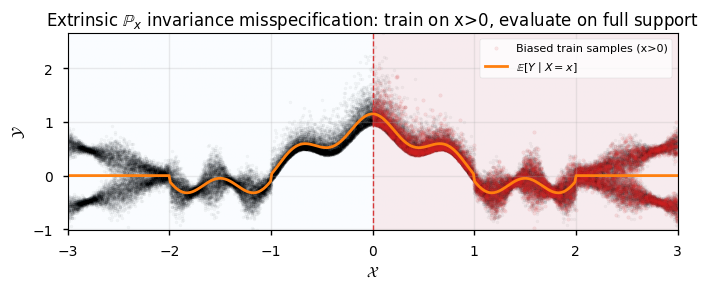

In [73]:
fig, ax = plt.subplots(figsize=(FIG_SIZE[0] * 1.3, FIG_SIZE[1] ))

# Background: full-support data distribution
scatter_with_density(x_eval.numpy(), y_eval.numpy(), ax=ax, alpha_points=0.03, s=5)

# Overlay: biased train samples (x>0 only)
ax.scatter(x_tr.numpy(), y_tr.numpy(), s=6, color="tab:red", alpha=0.10, label="Biased train samples (x>0)")

# True conditional expectation curve
x_grid_raw = torch.linspace(-3.0, 3.0, 500).reshape(-1, 1)
y_true_raw = true_condexp_1d(x_grid_raw)
ax.plot(x_grid_raw.numpy(), y_true_raw.numpy(), color="tab:orange", lw=2.0, label=r"$\mathbb{E}[Y\mid X=x]$")

# Visual cue of sampled training half-space
ax.axvspan(0.0, 3.0, color="tab:red", alpha=0.08, zorder=0)
ax.axvline(0.0, color="tab:red", ls="--", lw=1.0, alpha=0.9)

ax.set_title(r"Extrinsic $\mathbb{P}_x$ invariance misspecification: train on x>0, evaluate on full support")
ax.set_xlabel(r"$\mathcal{X}$")
ax.set_ylabel(r"$\mathcal{Y}$")
ax.set_xlim(-3.0, 3.0)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(PLOT_PATH / "misspec_px_protocol.png", dpi=220)
plt.show()


### 2.2 Model Training Under Biased Support

<div style="margin-left: 1.25em;">
We compare <code>NCP</code> (symmetry-agnostic) against <code>eNCP</code> (symmetry-constrained)
with matched backbone size and optimization settings. This isolates the effect of the symmetry prior
under marginal-support misspecification.
</div>


Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/ncp_px_extrinsic_model_N=20000_seed=10.pth
Loaded - best val objective: -2.72302
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/encp_px_extrinsic_model_N=20000_seed=10.pth
Loaded - best val objective: -3.09575


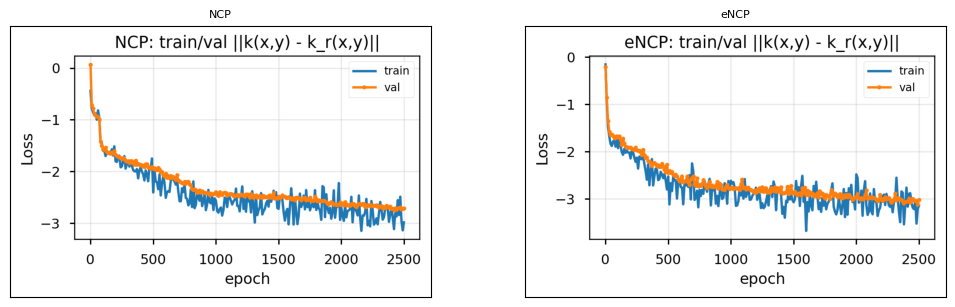

In [74]:
# Reflection symmetry group C2 representations are defined in setup and reused here.

BATCH_NORM = False
ORTH_REG = 0.01
CENTERING_REG = 0.01
MOMENTUM = 0.99


def make_ncp_model():
    return NCP(
        embedding_x=ResidualEncoder(
            MLP(
                in_dim=1,
                out_dim=EMBEDDING_DIM,
                hidden_units=[EMBEDDING_DIM * 2] * 2,
                activation=torch.nn.ELU(),
                bias=True,
                batch_norm=BATCH_NORM,
            ),
            in_dim=1,
        ),
        embedding_y=ResidualEncoder(
            MLP(
                in_dim=1,
                out_dim=EMBEDDING_DIM,
                hidden_units=[EMBEDDING_DIM * 2] * 2,
                activation=torch.nn.ELU(),
                bias=True,
                batch_norm=BATCH_NORM,
            ),
            in_dim=1,
        ),
        embedding_dim_x=EMBEDDING_DIM + 1,
        embedding_dim_y=EMBEDDING_DIM + 1,
        orth_reg=ORTH_REG,
        centering_reg=CENTERING_REG,
        momentum=MOMENTUM,
    ).to(DEVICE)


def make_encp_model():
    x_embedding = iMLP(
        in_rep=x_rep,
        out_dim=EMBEDDING_DIM,
        hidden_units=[EMBEDDING_DIM * 2] * 2,
        activation=torch.nn.ELU(),
        bias=True,
    )
    y_embedding = iMLP(
        in_rep=y_rep,
        out_dim=EMBEDDING_DIM,
        hidden_units=[EMBEDDING_DIM * 2] * 2,
        activation=torch.nn.ELU(),
        bias=True,
    )
    return ENCP(
        embedding_x=x_embedding,
        embedding_y=y_embedding,
        orth_reg=ORTH_REG,
        centering_reg=CENTERING_REG,
        momentum=MOMENTUM,
    ).to(DEVICE)


checkpoint_meta = {
    "seed": SEED,
    "embedding_dim": EMBEDDING_DIM,
    "batch_size": BATCH_SIZE,
    "misspecification": "Px_extrinsic_positive_halfspace",
}

ncp = make_ncp_model()
encp = make_encp_model()

ncp_optimizer = torch.optim.Adam(ncp.parameters(), lr=NCP_LR)
encp_optimizer = torch.optim.Adam(encp.parameters(), lr=NCP_LR)

ncp_checkpoint = CHECKPOINT_PATH / f"ncp_px_extrinsic_model_N={N:d}_seed={SEED:d}.pth"
encp_checkpoint = CHECKPOINT_PATH / f"encp_px_extrinsic_model_N={N:d}_seed={SEED:d}.pth"

best_ncp_state, best_ncp_val = fit_or_load_ncp_like(
    model=ncp,
    train_loader=train_dl,
    val_loader=val_dl,
    optimizer=ncp_optimizer,
    checkpoint_path=ncp_checkpoint,
    device=DEVICE,
    train_epochs=EPOCHS,
    check_every=CHECK_EVERY,
    patience=PATIENCE,
    plot_freq=PLOT_FREQ,
    enable_plots=False,
    desc="Training NCP (extrinsic Px)",
    plot_title="NCP: train/val ||k(x,y) - k_r(x,y)||",
    checkpoint_meta=checkpoint_meta,
)

best_encp_state, best_encp_val = fit_or_load_ncp_like(
    model=encp,
    train_loader=train_dl,
    val_loader=val_dl,
    optimizer=encp_optimizer,
    checkpoint_path=encp_checkpoint,
    device=DEVICE,
    train_epochs=EPOCHS,
    check_every=CHECK_EVERY,
    patience=PATIENCE,
    plot_freq=PLOT_FREQ,
    enable_plots=False,
    desc="Training eNCP (extrinsic Px)",
    plot_title="eNCP: train/val ||k(x,y) - k_r(x,y)||",
    checkpoint_meta=checkpoint_meta,
)

ncp.load_state_dict(best_ncp_state)
encp.load_state_dict(best_encp_state)
ncp.eval()
encp.eval()

fig_curves, _ = plot_saved_training_curves_panel(
    [("NCP", ncp_checkpoint), ("eNCP", encp_checkpoint)],
    figsize=(FIG_SIZE[0] * 1.9, FIG_SIZE[1] * 1.05),
)
plt.show()


### 2.3 Confidence Intervals on Full Support

<div style="margin-left: 1.25em;">
We estimate cCDFs and extract confidence intervals (CIs) for both models over the full $x$ range.
The boundary $x=0$ separates nominal support ($x>0$) from out-of-distribution support ($x<0$)
under the training protocol.
</div>


In [ ]:
# Fit linear decoders h(y) -> y (standardized)
dec_dl = DataLoader(TensorDataset(y_tr_c, y_tr_c), batch_size=BATCH_SIZE, shuffle=False)
ncp_lin_decoder = ncp.fit_linear_decoder(train_dataloader=dec_dl)
encp_lin_decoder = encp.fit_linear_decoder(train_dataloader=dec_dl)

# cCDF estimators
ccdf_kwargs = dict(random_state=int(SEED), subsample=None, u_eps=1e-5, output_distribution="normal")
ncp_ccdf = NCPConditionalCDF(
    model=ncp,
    y_train=y_tr_c,
    support_discretization_points=200,
    support_strategy="quantile_transformer",
    discretizer_kwargs=ccdf_kwargs,
)
encp_ccdf = ENCPConditionalCDF(
    model=encp,
    y_train=y_tr_c,
    y_rep=y_rep,
    support_discretization_points=200,
    support_strategy="quantile_transformer",
    discretizer_kwargs=ccdf_kwargs,
)

# Full x-grid in raw and standardized coordinates
x_grid = torch.linspace(-3.0, 3.0, 220).reshape(-1, 1)
x_grid_c = (x_grid - x_mean) / x_std
x_grid_c_np = x_grid_c.numpy().ravel()

quantile_levels = [0.10, 0.30]
model_specs = [("NCP", ncp_ccdf), ("eNCP", encp_ccdf)]

fig, axs = plt.subplots(1, 2, figsize=(FIG_SIZE[0] * 2.5, FIG_SIZE[1] ), sharex=True, sharey=True)
axs = np.atleast_1d(axs)

x0_c = float(((torch.tensor([[0.0]]) - x_mean) / x_std).item())

for ax, (model_name, ccdf_model) in zip(axs, model_specs):
    q_bands = {}
    for alpha in quantile_levels:
        q_lo, q_up = ccdf_model.conditional_quantiles(x_cond=x_grid_c, alpha=alpha)
        q_bands[f"{model_name} {(1 - alpha) * 100:.0f}% CI"] = (np.asarray(q_lo).ravel(), np.asarray(q_up).ravel())

    plot_expectations_with_quantiles(
        x_train=x_eval_c.numpy().ravel(),
        y_train=y_eval_c.numpy().ravel(),
        x_grid=x_grid_c_np,
        expectations=None,
        est_quantiles=q_bands,
        quantile_colors=["teal", "gold"],
        true_quantiles=None,
        ax=ax,
    )
    ax.axvline(x0_c, color="tab:red", ls="--", lw=1.2, alpha=0.95)
    ax.text(x0_c + 0.03, ax.get_ylim()[1] * 0.92, "x=0 boundary", color="tab:red", fontsize=8)
    ax.set_title(f"{model_name} CIs | train dataset support: x>0")

axs[-1].set_xlabel(r"$\mathcal{X}$ (standardized)")
fig.tight_layout()
fig.savefig(PLOT_PATH / "misspec_px_quantile_predictions.png", dpi=220)
plt.show()


### 2.4 Side-wise Error Decomposition

We report metrics on three supports:
- `train support` ($x>0$): nominal in-support regime,
- `ood support` ($x<0$): out-of-distribution regime,
- `full support`: combined regime.

<div style="margin-left: 1.25em;">
Metrics include mean CI coverage error, mean CI size, and conditional-expectation MAE,
aggregated over confidence levels.
</div>


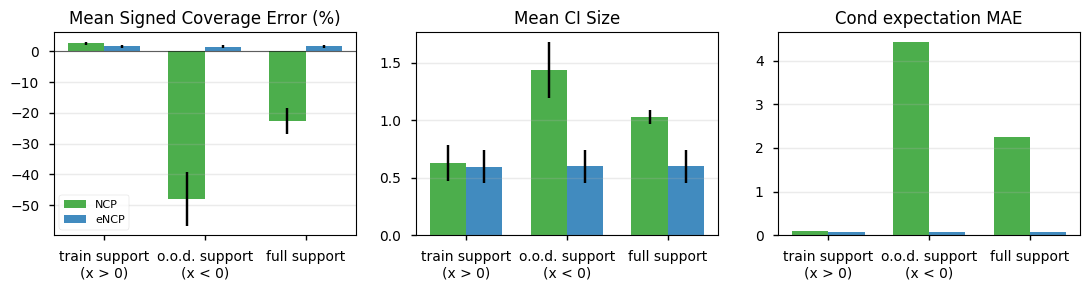

In [ ]:
@torch.no_grad()
def coverage_and_size_for_subset(ccdf_model, x_subset_c, y_subset_c, alpha, batch_size=BATCH_SIZE):
    dl = DataLoader(TensorDataset(x_subset_c, y_subset_c), batch_size=batch_size, shuffle=False)
    cov, size, n = 0.0, 0.0, 0
    for xb, yb in dl:
        q_lo, q_up = ccdf_model.conditional_quantiles(x_cond=xb, alpha=alpha)
        q_lo = torch.as_tensor(q_lo, dtype=torch.float32)
        q_up = torch.as_tensor(q_up, dtype=torch.float32)
        inside = ((q_lo <= yb) & (yb <= q_up)).float().mean()
        seg = (q_up - q_lo).abs().mean()
        cov += float(inside.item())
        size += float(seg.item())
        n += 1
    return cov / max(n, 1), size / max(n, 1)


@torch.no_grad()
def condexp_mae_for_subset(model, lin_decoder, x_subset_c, y_true_subset_c):
    pred = model.conditional_expectation(x=x_subset_c.to(DEVICE), hy2zy=lin_decoder).detach().cpu()
    return float((pred - y_true_subset_c).abs().mean().item())


side_masks = split_x_side_masks(x_eval)
alpha_values = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
model_ccdfs = {"NCP": ncp_ccdf, "eNCP": encp_ccdf}

rows_alpha = []
for alpha in alpha_values:
    desired = (1.0 - alpha) * 100.0
    for model_name, ccdf_model in model_ccdfs.items():
        for side_name, mask in side_masks.items():
            x_sub = x_eval_c[mask]
            y_sub = y_eval_c[mask]
            cov, ci_size = coverage_and_size_for_subset(ccdf_model, x_sub, y_sub, alpha)
            rows_alpha.append(
                {
                    "model": model_name,
                    "side": side_name,
                    "alpha": float(alpha),
                    "desired_coverage_pct": float(desired),
                    "coverage_pct": float(cov * 100.0),
                    "signed_coverage_error_pct": float(cov * 100.0 - desired),
                    "abs_coverage_error_pct": float(abs(cov * 100.0 - desired)),
                    "ci_size": float(ci_size),
                    "num_samples": int(mask.sum().item()),
                }
            )

df_side_alpha = pd.DataFrame(rows_alpha)

# Conditional expectation MAE by side
z_eval_true_c = (true_condexp_1d(x_eval) - y_mean) / y_std
rows_mae = []
for model_name, model, lin_dec in [
    ("NCP", ncp, ncp_lin_decoder),
    ("eNCP", encp, encp_lin_decoder),
]:
    for side_name, mask in side_masks.items():
        mae = condexp_mae_for_subset(model, lin_dec, x_eval_c[mask], z_eval_true_c[mask])
        rows_mae.append({"model": model_name, "side": side_name, "condexp_mae": mae, "num_samples": int(mask.sum().item())})

df_side_mae = pd.DataFrame(rows_mae)

def sem(x):
    arr = np.asarray(x, dtype=float)
    if arr.size <= 1:
        return 0.0
    return float(arr.std(ddof=1) / np.sqrt(arr.size))


# Aggregate summary
df_side_summary = (
    df_side_alpha.groupby(["model", "side"], as_index=False)
    .agg(
        mean_signed_coverage_error_pct=("signed_coverage_error_pct", "mean"),
        sem_signed_coverage_error_pct=("signed_coverage_error_pct", sem),
        mean_abs_coverage_error_pct=("abs_coverage_error_pct", "mean"),
        mean_coverage_error_pct=("abs_coverage_error_pct", "mean"),
        mean_ci_size=("ci_size", "mean"),
        sem_ci_size=("ci_size", sem),
    )
    .merge(df_side_mae, on=["model", "side"], how="left")
)

alpha_csv = METRICS_PATH / f"misspec_px_side_alpha_metrics_N={N:d}_seed={SEED:d}.csv"
summary_csv = METRICS_PATH / f"misspec_px_side_summary_N={N:d}_seed={SEED:d}.csv"
df_side_alpha.to_csv(alpha_csv, index=False)
df_side_summary.to_csv(summary_csv, index=False)

# Compact comparison plots for side-wise summary
plot_sides = ["right", "left", "full"]
plot_side_labels = ["train support\n(x > 0)", "o.o.d. support\n(x < 0)", "full support"]
models = ["NCP", "eNCP"]
colors = {"NCP": "tab:green", "eNCP": "tab:blue"}

fig, axs = plt.subplots(1, 3, figsize=(FIG_SIZE[0] * 2, FIG_SIZE[1] ), sharex=True)
axs = np.atleast_1d(axs)
x = np.arange(len(plot_sides), dtype=float)
width = 0.36

for m_idx, model_name in enumerate(models):
    df_m = df_side_summary[df_side_summary["model"] == model_name].set_index("side").reindex(plot_sides)
    xpos = x + (m_idx - (len(models) - 1) / 2) * width

    axs[0].bar(
        xpos,
        df_m["mean_signed_coverage_error_pct"].to_numpy(),
        yerr=df_m["sem_signed_coverage_error_pct"].to_numpy(),
        capsize=2,
        width=width,
        color=colors[model_name],
        alpha=0.85,
        label=model_name,
    )
    axs[1].bar(
        xpos,
        df_m["mean_ci_size"].to_numpy(),
        yerr=df_m["sem_ci_size"].to_numpy(),
        capsize=2,
        width=width,
        color=colors[model_name],
        alpha=0.85,
        label=model_name,
    )
    axs[2].bar(xpos, df_m["condexp_mae"].to_numpy(), width=width, color=colors[model_name], alpha=0.85, label=model_name)

axs[0].set_title("Mean Signed Coverage Error (%)")
axs[0].axhline(0.0, color="k", linewidth=0.8, alpha=0.6)
axs[1].set_title("Mean CI Size")
axs[2].set_title("Cond expectation MAE")


for ax in axs:
    ax.set_xticks(x)
    ax.set_xticklabels(plot_side_labels)
    # ax.set_yscale("log")
    ax.grid(True, axis="y", alpha=0.25)

axs[0].legend(fontsize=8)
# fig.suptitle("Extrinsic misspecification: side-wise generalization")
fig.tight_layout()
fig.savefig(PLOT_PATH / "misspec_px_sidewise_error_decomposition.png", dpi=220)
plt.show()


## 3. Incorrect Misspecification of Conditional Symmetry

Following [Wang et al. (2023)](https://proceedings.neurips.cc/paper_files/paper/2023/hash/7dc7793c89b93887e126a86f22ef63c6-Abstract-Conference.html), we now study the **incorrect** misspecification case: the marginal distribution is assumed to be $P_{x}$ $\mathbb{G}$-invariance, while the conditional distribution $P_{y\mid x}$ violates the assumed $\mathbb{G}$-invariance prior.

We consider the scenario of incorrect misspecification via:
  1. Unbiased violation: the amplitude of the heteroscedastic noise is increased only on one coset side. Crucially, this noise amplitude keeps the expected value $\mathbb{G}$-equivariant, but $P_{y\mid x}$ is no longer $\mathbb{G}$-invariant.
  2. Biased violation: the mean of the conditional distribution is shifted on one coset side, breaking both the $\mathbb{G}$-equivariance of the expected value and the $\mathbb{G}$-invariance of $P_{y\mid x}$.

### Analysis of results: Unbiased incorrect misspecification

In this experiment, we increase the scale of the heteroscedastic noise *only* on a subset of the support of the conditioning variable, specifically for $(x>1)$. We test the models performance over an increasing range of noise scales $C \in \{1,1.5,2,3,4,6\}$ with 1 recovering the original dataset and 6 being the most extreme perturbation. As depicted below:

<div align="center">
  <img src="./plots/incorrect_conditional_protocol_C=2.png" width="48%" />
  <img src="./plots/incorrect_conditional_protocol_C=6.png" width="48%" />
</div>

We study the performance of the NCP and eNCP models both on the perturbed and unperturbed regions of the support, as well as on the full support. As expected, the assumed $\mathbb{G}$-invariance of the conditional distribution results in the eNCP model providing increasingly more conservative CIs on the left-unperturbed regions, while producing less conservative CIs on the right-perturbed regions. Crucially the performance decrease stays focused on the support of the perturbation, and appears to be continuous with respect to the noise scale $C$.

<div align="center">
  <img src="./plots/incorrect_conditional_metrics_vs_C_regions_3x3.png" width="75%" />
</div>

This can also be observed qualitatively in the following CIs prediction plots of the different scales. 

<div align="center">
  <img src="./plots/incorrect_conditional_ci_predictions_all_C.png" width="70%" />
</div>

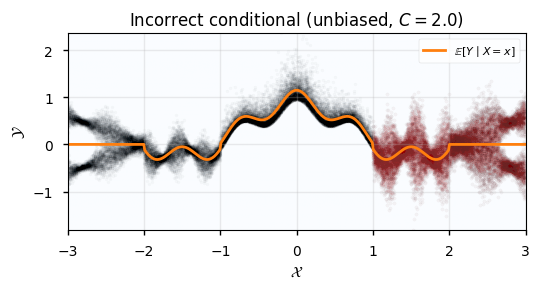

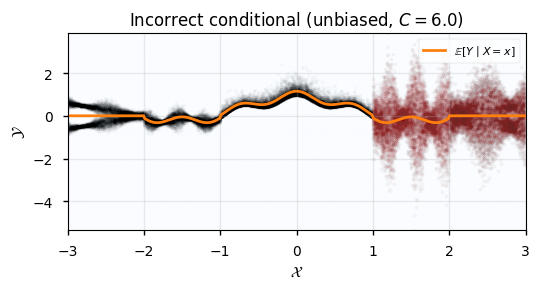


=== Running incorrect-conditional sweep for C=1.0 ===
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/ncp_incorrect_conditional_C=1_N=20000_seed=510.pth
Loaded - best val objective: -2.56768
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/encp_incorrect_conditional_C=1_N=20000_seed=510.pth
Loaded - best val objective: -2.87385

=== Running incorrect-conditional sweep for C=1.5 ===
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/ncp_incorrect_conditional_C=1p5_N=20000_seed=510.pth
Loaded - best val objective: -2.28798
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/encp_incorrect_conditional_C=1p5_N=20000_seed=510.pth
Loaded - best val objective: -2.63645

=== Running

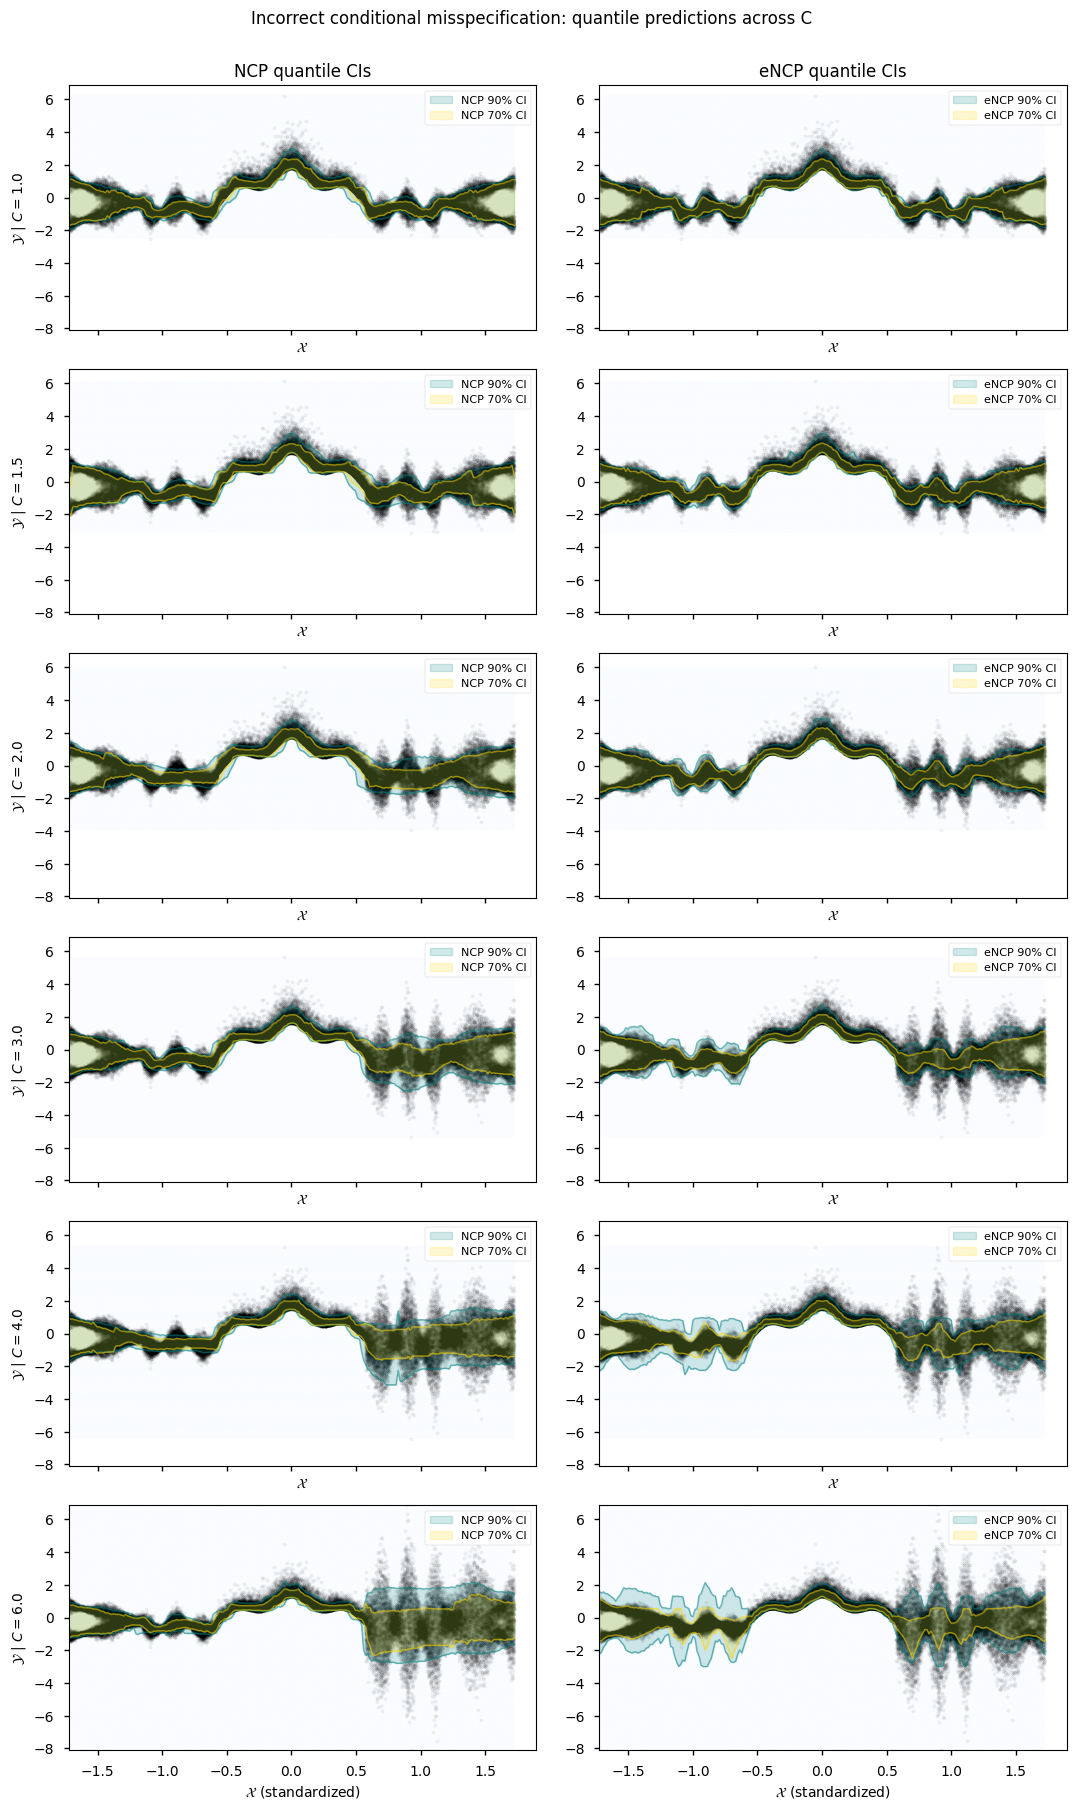

Saved regional summary-over-C metrics: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/plots/metrics/incorrect_conditional_regions_summary_over_C_N=20000_seed=510.csv


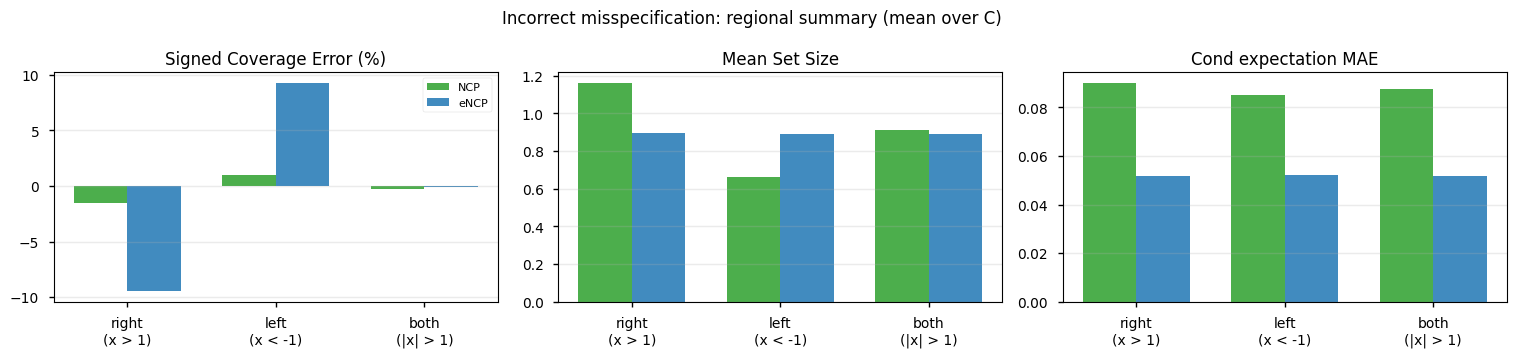

In [ ]:
SEED_INC = SEED + 500
C_SWEEP = [1.0, 1.5, 2.0, 3.0, 4.0, 6.0]
EVAL_N_METRICS = 50_000
alpha_values_sweep = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
quantile_levels_sweep = [0.10, 0.30]


@torch.no_grad()
def coverage_and_size_overall(ccdf_model, x_c, y_c, alpha):
    dl = DataLoader(TensorDataset(x_c, y_c), batch_size=BATCH_SIZE, shuffle=False)
    inside_sum, width_sum, n_total = 0.0, 0.0, 0
    for xb, yb in dl:
        q_lo, q_up = ccdf_model.conditional_quantiles(x_cond=xb, alpha=alpha)
        q_lo = torch.as_tensor(q_lo, dtype=torch.float32)
        q_up = torch.as_tensor(q_up, dtype=torch.float32)
        inside = ((q_lo <= yb) & (yb <= q_up)).float()
        widths = (q_up - q_lo).abs()
        inside_sum += float(inside.sum().item())
        width_sum += float(widths.sum().item())
        n_total += int(yb.numel())
    n_total = max(n_total, 1)
    return inside_sum / n_total, width_sum / n_total


@torch.no_grad()
def condexp_mae_overall(model, lin_decoder, x_c, z_true_c):
    pred = model.conditional_expectation(x=x_c.to(DEVICE), hy2zy=lin_decoder).detach().cpu()
    return float((pred - z_true_c).abs().mean().item())


def region_masks_from_x_raw(x_raw):
    x = x_raw.reshape(-1)
    return {
        "left": x < -1.0,
        "right": x > 1.0,
        "both": x.abs() > 1.0,
    }


# Visual examples of the unbiased perturbation protocol for representative scales
PROTOCOL_C_SHOW = [2.0, 6.0]
for c_vis in PROTOCOL_C_SHOW:
    x_vis, y_vis = make_condexp_1d_dataset_incorrect_conditional(
        n=EVAL_N,
        seed=SEED_INC + 30_000,
        c_rhs=c_vis,
    )

    x_vis_np = x_vis.numpy().ravel()
    y_vis_np = y_vis.numpy().ravel()
    mask_rhs_sym = (x_vis_np > 1.0) & (x_vis_np <= 2.0)
    mask_rhs_bi = x_vis_np > 2.0

    fig_p, ax_p = plt.subplots(figsize=(FIG_SIZE[0] * 1.0, FIG_SIZE[1] * 1.0))
    scatter_with_density(x_vis_np, y_vis_np, ax=ax_p, alpha_points=0.02, s=5)
    ax_p.scatter(
        x_vis_np[mask_rhs_sym],
        y_vis_np[mask_rhs_sym],
        s=7,
        alpha=0.02,
        color="tab:red",
        # label=r"Perturbed samples ($1<x\leq 2$)",
    )
    ax_p.scatter(
        x_vis_np[mask_rhs_bi],
        y_vis_np[mask_rhs_bi],
        s=7,
        alpha=0.02,
        color="firebrick",
        # label=r"Perturbed samples ($x>2$)",
    )

    x_vis_grid = torch.linspace(-3.0, 3.0, 500).reshape(-1, 1)
    y_vis_true = true_condexp_1d(x_vis_grid)
    ax_p.plot(x_vis_grid.numpy(), y_vis_true.numpy(), color="tab:orange", lw=2.0, label=r"$\mathbb{E}[Y\mid X=x]$")

    ax_p.set_title(rf"Incorrect conditional (unbiased, $C={c_vis:.1f}$)")
    ax_p.set_xlabel(r"$\mathcal{X}$")
    ax_p.set_ylabel(r"$\mathcal{Y}$")
    ax_p.set_xlim(-3.0, 3.0)
    ax_p.grid(True, alpha=0.25)
    ax_p.legend(fontsize=8, loc="upper right")
    fig_p.tight_layout()

    c_vis_tag = int(c_vis) if float(c_vis).is_integer() else str(c_vis).replace('.', 'p')
    fig_p.savefig(PLOT_PATH / f"incorrect_conditional_protocol_C={c_vis_tag}.png", dpi=220)
    plt.show()

rows_region = []
fig_q, axs_q = plt.subplots(
    len(C_SWEEP),
    2,
    figsize=(FIG_SIZE[0] * 1 * 2, FIG_SIZE[1] * max(2.3, 1.0 * len(C_SWEEP))),
    sharex=True,
    sharey='col',
)
axs_q = np.atleast_2d(axs_q)

for i, c_value in enumerate(C_SWEEP):
    print(f"\n=== Running incorrect-conditional sweep for C={c_value:.1f} ===")

    x_c_raw, y_c_raw = make_condexp_1d_dataset_incorrect_conditional(
        n=N,
        seed=SEED_INC,
        c_rhs=c_value,
    )

    split_c = split_standardize_tensors(
        x_c_raw,
        y_c_raw,
        train_ratio=0.70,
        val_ratio=0.15,
        seed=SEED_INC,
        x_rep=x_rep,
        y_rep=y_rep,
    )

    x_tr_c, y_tr_c = split_c["x_tr_c"], split_c["y_tr_c"]
    x_val_c, y_val_c = split_c["x_val_c"], split_c["y_val_c"]
    x_mean_c, x_std_c = split_c["x_mean"], split_c["x_std"]
    y_mean_c, y_std_c = split_c["y_mean"], split_c["y_std"]

    x_eval_raw, y_eval_raw = make_condexp_1d_dataset_incorrect_conditional(
        n=EVAL_N,
        seed=SEED_INC + 10_000,
        c_rhs=c_value,
    )
    x_eval_c = (x_eval_raw - x_mean_c) / x_std_c
    y_eval_c = (y_eval_raw - y_mean_c) / y_std_c

    x_eval_metrics_raw, y_eval_metrics_raw = make_condexp_1d_dataset_incorrect_conditional(
        n=EVAL_N_METRICS,
        seed=SEED_INC + 20_000,
        c_rhs=c_value,
    )
    x_eval_metrics_c = (x_eval_metrics_raw - x_mean_c) / x_std_c
    y_eval_metrics_c = (y_eval_metrics_raw - y_mean_c) / y_std_c

    x_grid_raw = torch.linspace(-3.0, 3.0, 220).reshape(-1, 1)
    x_grid_c = (x_grid_raw - x_mean_c) / x_std_c
    x_grid_c_np = x_grid_c.numpy().ravel()

    train_dl_c = DataLoader(TensorDataset(x_tr_c, y_tr_c), batch_size=BATCH_SIZE, shuffle=True)
    val_dl_c = DataLoader(TensorDataset(x_val_c, y_val_c), batch_size=BATCH_SIZE, shuffle=False)

    ncp_c = make_ncp_model()
    encp_c = make_encp_model()

    ncp_opt_c = torch.optim.Adam(ncp_c.parameters(), lr=NCP_LR)
    encp_opt_c = torch.optim.Adam(encp_c.parameters(), lr=NCP_LR)

    c_tag = int(c_value) if float(c_value).is_integer() else str(c_value).replace('.', 'p')
    ncp_ckpt_c = CHECKPOINT_PATH / f"ncp_incorrect_conditional_C={c_tag}_N={N:d}_seed={SEED_INC:d}.pth"
    encp_ckpt_c = CHECKPOINT_PATH / f"encp_incorrect_conditional_C={c_tag}_N={N:d}_seed={SEED_INC:d}.pth"

    ckpt_meta_c = {
        "seed": SEED_INC,
        "embedding_dim": EMBEDDING_DIM,
        "batch_size": BATCH_SIZE,
        "misspecification": f"incorrect_conditional_rhs_noise_C={c_value:.1f}",
        "sweep": "C",
    }

    best_ncp_c_state, _ = fit_or_load_ncp_like(
        model=ncp_c,
        train_loader=train_dl_c,
        val_loader=val_dl_c,
        optimizer=ncp_opt_c,
        checkpoint_path=ncp_ckpt_c,
        device=DEVICE,
        train_epochs=EPOCHS,
        check_every=CHECK_EVERY,
        patience=PATIENCE,
        plot_freq=PLOT_FREQ,
        desc=rf"Training NCP (incorrect conditional, C={c_value:.1f})",
        plot_title=rf"NCP: train/val ||k(x,y)-k_r(x,y)|| | C={c_value:.1f}",
        checkpoint_meta=ckpt_meta_c,
        show_curve_on_load=False,
        enable_plots=False,
    )

    best_encp_c_state, _ = fit_or_load_ncp_like(
        model=encp_c,
        train_loader=train_dl_c,
        val_loader=val_dl_c,
        optimizer=encp_opt_c,
        checkpoint_path=encp_ckpt_c,
        device=DEVICE,
        train_epochs=EPOCHS,
        check_every=CHECK_EVERY,
        patience=PATIENCE,
        plot_freq=PLOT_FREQ,
        desc=rf"Training eNCP (incorrect conditional, C={c_value:.1f})",
        plot_title=rf"eNCP: train/val ||k(x,y)-k_r(x,y)|| | C={c_value:.1f}",
        checkpoint_meta=ckpt_meta_c,
        show_curve_on_load=False,
        enable_plots=False,
    )

    ncp_c.load_state_dict(best_ncp_c_state)
    encp_c.load_state_dict(best_encp_c_state)
    ncp_c.eval()
    encp_c.eval()

    dec_dl_c = DataLoader(TensorDataset(y_tr_c, y_tr_c), batch_size=BATCH_SIZE, shuffle=False)
    ncp_lin_c = ncp_c.fit_linear_decoder(train_dataloader=dec_dl_c)
    encp_lin_c = encp_c.fit_linear_decoder(train_dataloader=dec_dl_c)

    ccdf_kwargs_c = dict(random_state=int(SEED_INC), subsample=None, u_eps=1e-5, output_distribution="normal")
    ncp_ccdf_c = NCPConditionalCDF(
        model=ncp_c,
        y_train=y_tr_c,
        support_discretization_points=200,
        support_strategy="quantile_transformer",
        discretizer_kwargs=ccdf_kwargs_c,
    )
    encp_ccdf_c = ENCPConditionalCDF(
        model=encp_c,
        y_train=y_tr_c,
        y_rep=y_rep,
        support_discretization_points=200,
        support_strategy="quantile_transformer",
        discretizer_kwargs=ccdf_kwargs_c,
    )

    z_true_metrics_c = (true_condexp_1d(x_eval_metrics_raw) - y_mean_c) / y_std_c
    region_masks = region_masks_from_x_raw(x_eval_metrics_raw)

    for j, (model_name, model_obj, lin_dec, ccdf_model) in enumerate(
        [
            ("NCP", ncp_c, ncp_lin_c, ncp_ccdf_c),
            ("eNCP", encp_c, encp_lin_c, encp_ccdf_c),
        ]
    ):
        ax = axs_q[i, j]
        q_bands = {}
        for alpha in quantile_levels_sweep:
            q_lo, q_up = ccdf_model.conditional_quantiles(x_cond=x_grid_c, alpha=alpha)
            q_bands[f"{model_name} {(1 - alpha) * 100:.0f}% CI"] = (
                np.asarray(q_lo).ravel(),
                np.asarray(q_up).ravel(),
            )

        plot_expectations_with_quantiles(
            x_train=x_eval_c.numpy().ravel(),
            y_train=y_eval_c.numpy().ravel(),
            x_grid=x_grid_c_np,
            expectations=None,
            est_quantiles=q_bands,
            quantile_colors=["teal", "gold"],
            true_quantiles=None,
            ax=ax,
        )

        if i == 0:
            ax.set_title(f"{model_name} quantile CIs")
        if j == 0:
            ax.set_ylabel(rf"$\mathcal{{Y}}$ | $C={c_value:.1f}$")
        else:
            ax.set_ylabel("")
        if i == len(C_SWEEP) - 1:
            ax.set_xlabel(r"$\mathcal{X}$ (standardized)")

        for region_name, region_mask in region_masks.items():
            x_reg = x_eval_metrics_c[region_mask]
            y_reg = y_eval_metrics_c[region_mask]
            z_reg = z_true_metrics_c[region_mask]
            n_reg = int(region_mask.sum().item())
            if n_reg == 0:
                continue

            cov_errs, set_sizes = [], []
            for alpha in alpha_values_sweep:
                cov, set_size = coverage_and_size_overall(ccdf_model, x_reg, y_reg, alpha)
                cov_errs.append(cov * 100.0 - (1 - alpha) * 100.0)
                set_sizes.append(set_size)

            mae = condexp_mae_overall(model_obj, lin_dec, x_reg, z_reg)

            rows_region.append(
                {
                    "model": model_name,
                    "region": region_name,
                    "C_rhs": float(c_value),
                    "n_eval_region": n_reg,
                    "mean_coverage_error_pct": float(np.mean(cov_errs)),
                    "mean_set_size": float(np.mean(set_sizes)),
                    "condexp_mae": float(mae),
                }
            )


fig_q.suptitle("Incorrect conditional misspecification: quantile predictions across C", y=1.003)
fig_q.tight_layout()
fig_q.savefig(PLOT_PATH / "incorrect_conditional_ci_predictions_all_C.png", dpi=220)
plt.show()


df_c_sweep_regions = pd.DataFrame(rows_region).sort_values(["region", "model", "C_rhs"]).reset_index(drop=True)

c_sweep_regions_csv = METRICS_PATH / f"incorrect_conditional_c_sweep_regions_summary_N={N:d}_seed={SEED_INC:d}.csv"
df_c_sweep_regions.to_csv(c_sweep_regions_csv, index=False)
# Compact regional summary across C (analogous report to section 2)
df_regions_summary_over_c = (
    df_c_sweep_regions.groupby(["model", "region"], as_index=False)
    .agg(
        mean_signed_coverage_error_pct=("mean_coverage_error_pct", "mean"),
        mean_set_size=("mean_set_size", "mean"),
        mean_condexp_mae=("condexp_mae", "mean"),
    )
)

regions_summary_csv = METRICS_PATH / f"incorrect_conditional_regions_summary_over_C_N={N:d}_seed={SEED_INC:d}.csv"
df_regions_summary_over_c.to_csv(regions_summary_csv, index=False)
print(f"Saved regional summary-over-C metrics: {regions_summary_csv}")

plot_regions = ["right", "left", "both"]
plot_region_labels = ["right\n(x > 1)", "left\n(x < -1)", "both\n(|x| > 1)"]
models = ["NCP", "eNCP"]
colors = {"NCP": "tab:green", "eNCP": "tab:blue"}

fig_sum, axs_sum = plt.subplots(1, 3, figsize=(FIG_SIZE[0] * 2.8, FIG_SIZE[1] * 1.2), sharex=True)
axs_sum = np.atleast_1d(axs_sum)
x = np.arange(len(plot_regions), dtype=float)
width = 0.36

for m_idx, model_name in enumerate(models):
    df_m = (
        df_regions_summary_over_c[df_regions_summary_over_c["model"] == model_name]
        .set_index("region")
        .reindex(plot_regions)
    )
    xpos = x + (m_idx - (len(models) - 1) / 2) * width

    axs_sum[0].bar(xpos, df_m["mean_signed_coverage_error_pct"].to_numpy(), width=width, color=colors[model_name], alpha=0.85, label=model_name)
    axs_sum[1].bar(xpos, df_m["mean_set_size"].to_numpy(), width=width, color=colors[model_name], alpha=0.85, label=model_name)
    axs_sum[2].bar(xpos, df_m["mean_condexp_mae"].to_numpy(), width=width, color=colors[model_name], alpha=0.85, label=model_name)

axs_sum[0].set_title("Signed Coverage Error (%)")
axs_sum[1].set_title("Mean Set Size")
axs_sum[2].set_title("Cond expectation MAE")

for ax in axs_sum:
    ax.set_xticks(x)
    ax.set_xticklabels(plot_region_labels)
    ax.grid(True, axis="y", alpha=0.25)

axs_sum[0].legend(fontsize=8)
fig_sum.suptitle("Incorrect misspecification: regional summary (mean over C)")
fig_sum.tight_layout()
fig_sum.savefig(PLOT_PATH / "incorrect_conditional_regions_summary_over_C.png", dpi=220)
plt.show()

### 3.2 Plots comparing the performance of the models across the different scales of noise perturbation

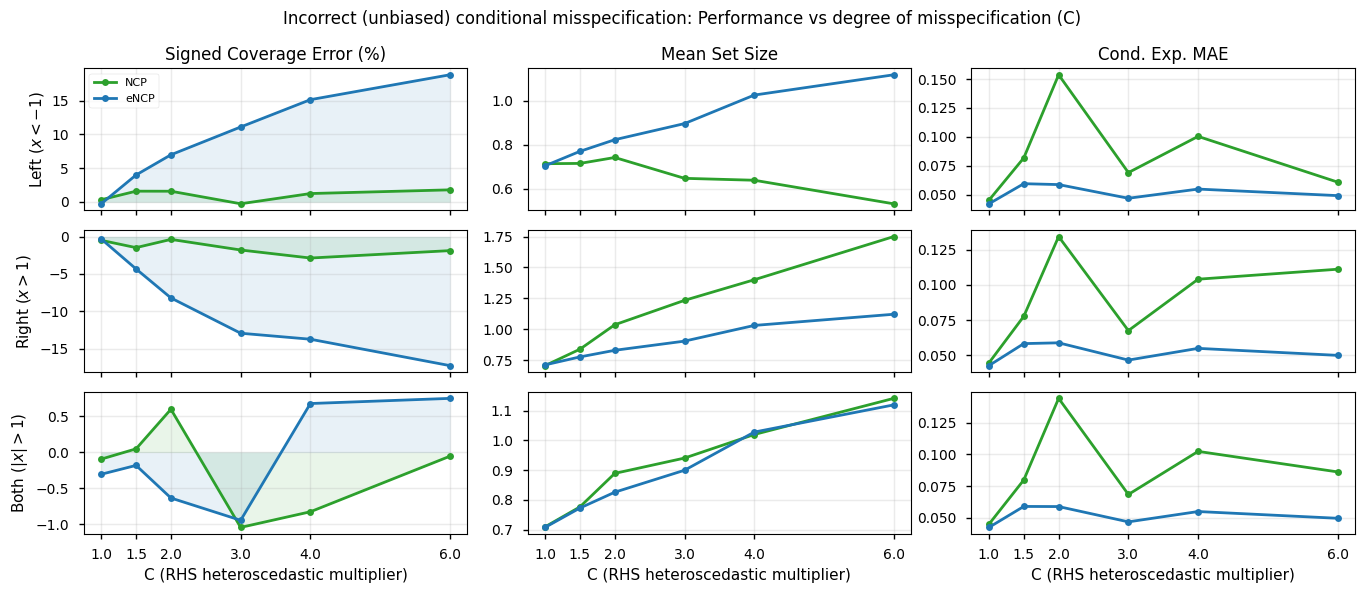

In [ ]:
if "df_c_sweep_regions" not in globals():
    df_c_sweep_regions = pd.read_csv(c_sweep_regions_csv)

plot_metrics = [
    ("mean_coverage_error_pct", "Signed Coverage Error (%)"),
    ("mean_set_size", "Mean Set Size"),
    ("condexp_mae", "Cond. Exp. MAE"),
]
regions_order = [
    ("left", r"Left ($x<-1$)"),
    ("right", r"Right ($x>1$)"),
    ("both", r"Both ($|x|>1$)"),
]
colors = {"NCP": "tab:green", "eNCP": "tab:blue"}

fig_r, axs_r = plt.subplots(3, 3, figsize=(FIG_SIZE[0] * 2.5, FIG_SIZE[1] * 2.0), sharex=True)
axs_r = np.asarray(axs_r)

for r_idx, (region_key, region_label) in enumerate(regions_order):
    for c_idx, (metric, metric_title) in enumerate(plot_metrics):
        ax = axs_r[r_idx, c_idx]
        for model_name in ["NCP", "eNCP"]:
            df_rm = df_c_sweep_regions[
                (df_c_sweep_regions["region"] == region_key) & (df_c_sweep_regions["model"] == model_name)
            ].sort_values("C_rhs")
            df_x = pd.DataFrame({"C_rhs": [float(c) for c in C_SWEEP]})
            df_plot = df_x.merge(df_rm[["C_rhs", metric]], on="C_rhs", how="left")
            x_vals = df_plot["C_rhs"].to_numpy(dtype=float)
            y_vals = df_plot[metric].to_numpy(dtype=float)
            ax.plot(
                x_vals,
                y_vals,
                marker="o",
                linewidth=2.0,
                markersize=5,
                color=colors[model_name],
                label=model_name,
            )
            if metric == "mean_coverage_error_pct":
                mask_fin = np.isfinite(y_vals)
                ax.fill_between(
                    x_vals[mask_fin],
                    np.zeros_like(y_vals[mask_fin]),
                    y_vals[mask_fin],
                    color=colors[model_name],
                    alpha=0.10,
                )

        if r_idx == 0:
            ax.set_title(metric_title)
        if c_idx == 0:
            ax.set_ylabel(region_label)
        if r_idx == len(regions_order) - 1:
            ax.set_xlabel("C (RHS heteroscedastic multiplier)")

        ax.set_xticks([float(c) for c in C_SWEEP])
        ax.grid(True, alpha=0.25)

axs_r[0, 0].legend(fontsize=8)
fig_r.suptitle("Incorrect (unbiased) conditional misspecification: Performance vs degree of misspecification (C)")
fig_r.tight_layout()
fig_r.savefig(PLOT_PATH / "incorrect_conditional_metrics_vs_C_regions_3x3.png", dpi=220)
plt.show()

### 3.3 Biased Incorrect Misspecification (Mean Shift on Right Side)

We now consider a **biased** incorrect misspecification in which we add a linear offset to the right-side conditional mean in the symmetric and bimodal regimes ($x>1$):

$$
Y \leftarrow Y + b(x-1), \quad x>1,
$$

where $b$ is a slope parameter controlling perturbation strength.

This perturbation breaks equivariance of the conditional mean (in contrast to the unbiased case). We sweep:

$$
b \in \{0, 0.5, 1.0, 2.0, 5.0\}
$$

and evaluate model behavior on the same regional splits (`left`, `right`, `both` with $|x|>1$).

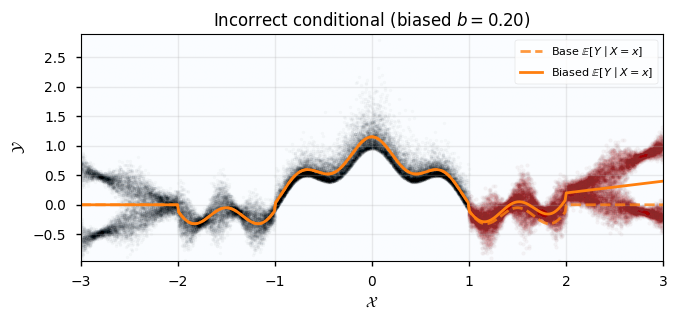

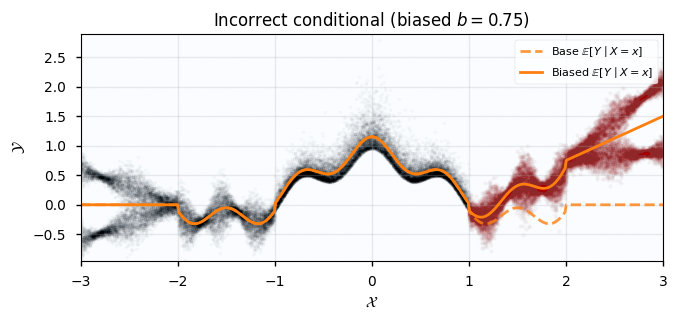

In [ ]:
SEED_BIAS = SEED + 1_500
B_SWEEP = [0.0, 0.2, 0.5, 0.75]
EVAL_N_METRICS_BIAS = 50_000
alpha_values_bias = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
quantile_levels_bias = [0.10, 0.30]


def region_masks_from_x_raw_bias(x_raw):
    x = x_raw.reshape(-1)
    return {
        "left": x < -1.0,
        "right": x > 1.0,
        "both": x.abs() > 1.0,
    }


# Representative protocol visualizations (biased mean shift)
B_PROTOCOL_SHOW = [0.2, 0.75]
for b_vis in B_PROTOCOL_SHOW:
    x_vis, y_vis = make_condexp_1d_dataset_incorrect_conditional_biased(
        n=EVAL_N,
        seed=SEED_BIAS + 30_000,
        slope_rhs=b_vis,
    )

    x_vis_np = x_vis.numpy().ravel()
    y_vis_np = y_vis.numpy().ravel()
    mask_rhs = x_vis_np > 1.0

    fig_bp, ax_bp = plt.subplots(figsize=(FIG_SIZE[0] * 1.25, FIG_SIZE[1] * 1.1))
    scatter_with_density(x_vis_np, y_vis_np, ax=ax_bp, alpha_points=0.02, s=5)
    ax_bp.scatter(
        x_vis_np[mask_rhs],
        y_vis_np[mask_rhs],
        s=7,
        alpha=0.025,
        color="tab:red",
        # label=r"Perturbed samples ($x>1$)",
    )

    x_vis_grid = torch.linspace(-3.0, 3.0, 500).reshape(-1, 1)
    y_base = true_condexp_1d(x_vis_grid)
    y_bias = true_condexp_1d_incorrect_conditional_biased(x_vis_grid, slope_rhs=b_vis)
    ax_bp.plot(x_vis_grid.numpy(), y_base.numpy(), color="tab:orange", lw=2.0, ls='--', alpha=0.8, label=r"Base $\mathbb{E}[Y\mid X=x]$")
    ax_bp.plot(x_vis_grid.numpy(), y_bias.numpy(), color="tab:orange", lw=2.0, label=r"Biased $\mathbb{E}[Y\mid X=x]$")

    ax_bp.set_title(rf"Incorrect conditional (biased $b={b_vis:.2f}$)")
    ax_bp.set_xlabel(r"$\mathcal{X}$")
    ax_bp.set_ylabel(r"$\mathcal{Y}$")
    ax_bp.set_xlim(-3.0, 3.0)
    ax_bp.grid(True, alpha=0.25)
    ax_bp.legend(fontsize=8, loc="upper right")
    fig_bp.tight_layout()

    b_tag = int(b_vis) if float(b_vis).is_integer() else str(b_vis).replace('.', 'p')
    fig_bp.savefig(PLOT_PATH / f"incorrect_conditional_biased_protocol_b={b_tag}.png", dpi=220)
    plt.show()



=== Running biased incorrect-conditional sweep for b=0.00 ===
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/ncp_incorrect_conditional_biased_b=0_N=20000_seed=1510.pth
Loaded - best val objective: -2.73293
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/encp_incorrect_conditional_biased_b=0_N=20000_seed=1510.pth
Loaded - best val objective: -3.12605

=== Running biased incorrect-conditional sweep for b=0.20 ===
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/ncp_incorrect_conditional_biased_b=0p2_N=20000_seed=1510.pth
Loaded - best val objective: -2.70478
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/checkpoints/encp_incorrect_conditional_biased_b=0p2_N=20000_seed=1510.pth
Lo

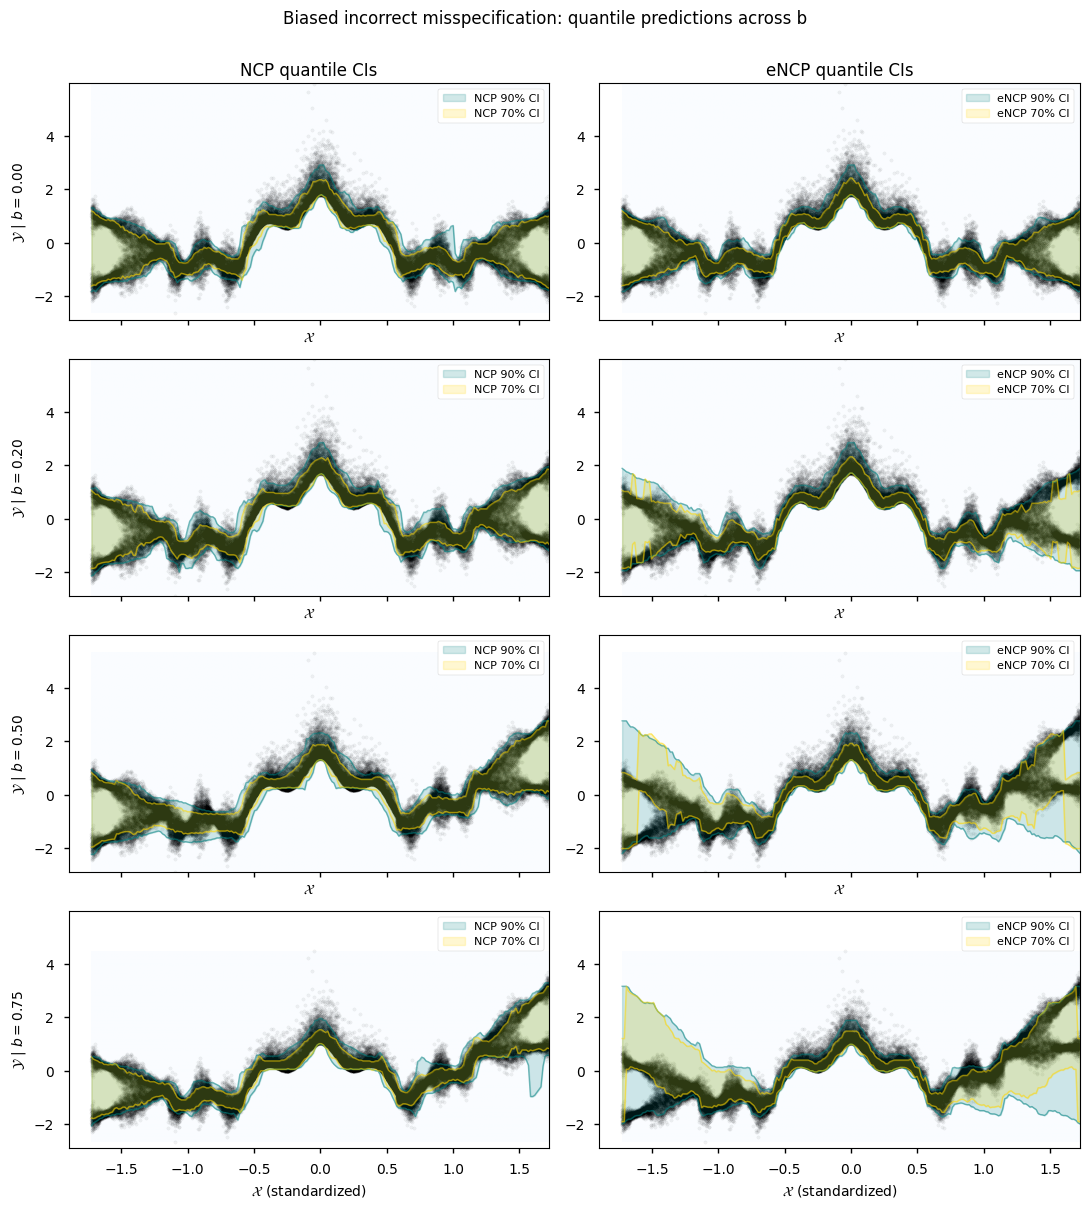

Saved biased regional b-sweep summary: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/plots/metrics/incorrect_conditional_biased_b_sweep_regions_summary_N=20000_seed=1510.csv
Saved biased regional summary-over-b metrics: /home/danfoa/Projects/symm_rep_learn/paper/examples/misspecified_sensitivity_analysis/plots/metrics/incorrect_conditional_biased_regions_summary_over_b_N=20000_seed=1510.csv


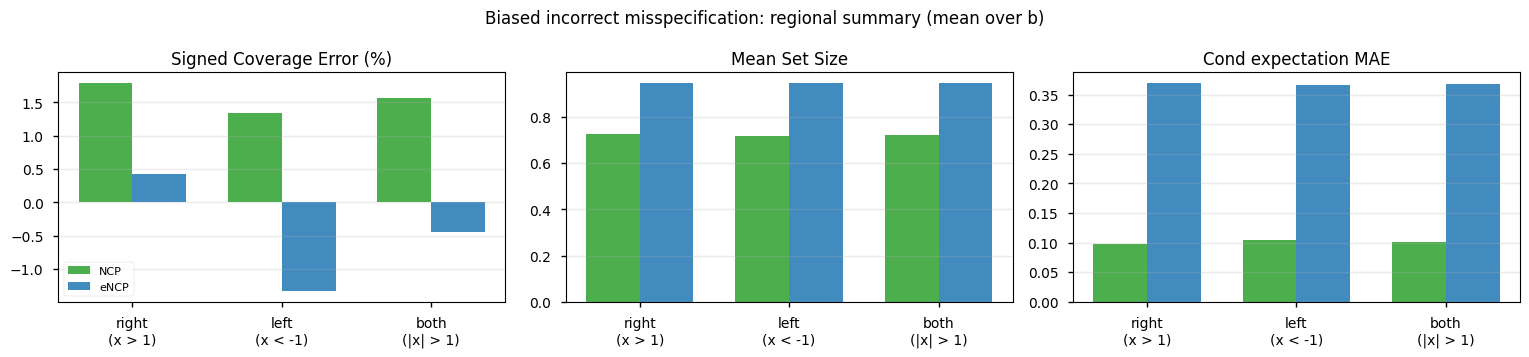

| model | region | mean_signed_coverage_error_pct | mean_set_size | mean_condexp_mae |
| --- | --- | --- | --- | --- |
| NCP | both | 1.568 | 0.722 | 0.101 |
| eNCP | both | -0.444 | 0.946 | 0.368 |
| NCP | left | 1.339 | 0.719 | 0.104 |
| eNCP | left | -1.333 | 0.946 | 0.366 |
| NCP | right | 1.792 | 0.725 | 0.098 |
| eNCP | right | 0.427 | 0.946 | 0.369 |


In [ ]:
rows_bias = []
fig_qb, axs_qb = plt.subplots(
    len(B_SWEEP),
    2,
    figsize=(FIG_SIZE[0] * 1 * 2, FIG_SIZE[1] * max(2.3, 1.0 * len(B_SWEEP))),
    sharex='row',
    sharey='col',
)
axs_qb = np.atleast_2d(axs_qb)

for i, b_value in enumerate(B_SWEEP):
    print(f"\n=== Running biased incorrect-conditional sweep for b={b_value:.2f} ===")

    x_b_raw, y_b_raw = make_condexp_1d_dataset_incorrect_conditional_biased(
        n=N,
        seed=SEED_BIAS,
        slope_rhs=b_value,
    )

    split_b = split_standardize_tensors(
        x_b_raw,
        y_b_raw,
        train_ratio=0.70,
        val_ratio=0.15,
        seed=SEED_BIAS,
        x_rep=x_rep,
        y_rep=y_rep,
    )

    x_tr_b, y_tr_b = split_b["x_tr_c"], split_b["y_tr_c"]
    x_val_b, y_val_b = split_b["x_val_c"], split_b["y_val_c"]
    x_mean_b, x_std_b = split_b["x_mean"], split_b["x_std"]
    y_mean_b, y_std_b = split_b["y_mean"], split_b["y_std"]

    x_eval_b_raw, y_eval_b_raw = make_condexp_1d_dataset_incorrect_conditional_biased(
        n=EVAL_N,
        seed=SEED_BIAS + 10_000,
        slope_rhs=b_value,
    )
    x_eval_b = (x_eval_b_raw - x_mean_b) / x_std_b
    y_eval_b = (y_eval_b_raw - y_mean_b) / y_std_b

    x_eval_metrics_b_raw, y_eval_metrics_b_raw = make_condexp_1d_dataset_incorrect_conditional_biased(
        n=EVAL_N_METRICS_BIAS,
        seed=SEED_BIAS + 20_000,
        slope_rhs=b_value,
    )
    x_eval_metrics_b = (x_eval_metrics_b_raw - x_mean_b) / x_std_b
    y_eval_metrics_b = (y_eval_metrics_b_raw - y_mean_b) / y_std_b

    x_grid_b_raw = torch.linspace(-3.0, 3.0, 220).reshape(-1, 1)
    x_grid_b = (x_grid_b_raw - x_mean_b) / x_std_b
    x_grid_b_np = x_grid_b.numpy().ravel()

    train_dl_b = DataLoader(TensorDataset(x_tr_b, y_tr_b), batch_size=BATCH_SIZE, shuffle=True)
    val_dl_b = DataLoader(TensorDataset(x_val_b, y_val_b), batch_size=BATCH_SIZE, shuffle=False)

    ncp_b = make_ncp_model()
    encp_b = make_encp_model()

    ncp_opt_b = torch.optim.Adam(ncp_b.parameters(), lr=NCP_LR)
    encp_opt_b = torch.optim.Adam(encp_b.parameters(), lr=NCP_LR / 2)

    b_tag = int(b_value) if float(b_value).is_integer() else str(b_value).replace('.', 'p')
    ncp_ckpt_b = CHECKPOINT_PATH / f"ncp_incorrect_conditional_biased_b={b_tag}_N={N:d}_seed={SEED_BIAS:d}.pth"
    encp_ckpt_b = CHECKPOINT_PATH / f"encp_incorrect_conditional_biased_b={b_tag}_N={N:d}_seed={SEED_BIAS:d}.pth"

    ckpt_meta_b = {
        "seed": SEED_BIAS,
        "embedding_dim": EMBEDDING_DIM,
        "batch_size": BATCH_SIZE,
        "misspecification": f"incorrect_conditional_rhs_mean_shift_b={b_value:.2f}",
        "sweep": "b",
    }

    best_ncp_b_state, _ = fit_or_load_ncp_like(
        model=ncp_b,
        train_loader=train_dl_b,
        val_loader=val_dl_b,
        optimizer=ncp_opt_b,
        checkpoint_path=ncp_ckpt_b,
        device=DEVICE,
        train_epochs=EPOCHS,
        check_every=CHECK_EVERY,
        patience=PATIENCE,
        plot_freq=PLOT_FREQ,
        desc=rf"Training NCP (biased incorrect conditional, b={b_value:.2f})",
        plot_title=rf"NCP: train/val ||k(x,y)-k_r(x,y)|| | b={b_value:.2f}",
        checkpoint_meta=ckpt_meta_b,
        show_curve_on_load=False,
        enable_plots=False,
    )

    best_encp_b_state, _ = fit_or_load_ncp_like(
        model=encp_b,
        train_loader=train_dl_b,
        val_loader=val_dl_b,
        optimizer=encp_opt_b,
        checkpoint_path=encp_ckpt_b,
        device=DEVICE,
        train_epochs=EPOCHS,
        check_every=CHECK_EVERY,
        patience=PATIENCE,
        plot_freq=PLOT_FREQ,
        desc=rf"Training eNCP (biased incorrect conditional, b={b_value:.2f})",
        plot_title=rf"eNCP: train/val ||k(x,y)-k_r(x,y)|| | b={b_value:.2f}",
        checkpoint_meta=ckpt_meta_b,
        show_curve_on_load=False,
        enable_plots=False,
    )

    ncp_b.load_state_dict(best_ncp_b_state)
    encp_b.load_state_dict(best_encp_b_state)
    ncp_b.eval()
    encp_b.eval()

    dec_dl_b = DataLoader(TensorDataset(y_tr_b, y_tr_b), batch_size=BATCH_SIZE, shuffle=False)
    ncp_lin_b = ncp_b.fit_linear_decoder(train_dataloader=dec_dl_b)
    encp_lin_b = encp_b.fit_linear_decoder(train_dataloader=dec_dl_b)

    ccdf_kwargs_b = dict(random_state=int(SEED_BIAS), subsample=None, u_eps=1e-5, output_distribution="normal")
    ncp_ccdf_b = NCPConditionalCDF(
        model=ncp_b,
        y_train=y_tr_b,
        support_discretization_points=200,
        support_strategy="quantile_transformer",
        discretizer_kwargs=ccdf_kwargs_b,
    )
    encp_ccdf_b = ENCPConditionalCDF(
        model=encp_b,
        y_train=y_tr_b,
        y_rep=y_rep,
        support_discretization_points=200,
        support_strategy="quantile_transformer",
        discretizer_kwargs=ccdf_kwargs_b,
    )

    z_true_metrics_b = (
        true_condexp_1d_incorrect_conditional_biased(x_eval_metrics_b_raw, slope_rhs=b_value) - y_mean_b
    ) / y_std_b
    region_masks_b = region_masks_from_x_raw_bias(x_eval_metrics_b_raw)

    for j, (model_name, model_obj, lin_dec, ccdf_model) in enumerate(
        [
            ("NCP", ncp_b, ncp_lin_b, ncp_ccdf_b),
            ("eNCP", encp_b, encp_lin_b, encp_ccdf_b),
        ]
    ):
        ax = axs_qb[i, j]
        q_bands = {}
        for alpha in quantile_levels_bias:
            q_lo, q_up = ccdf_model.conditional_quantiles(x_cond=x_grid_b, alpha=alpha)
            q_bands[f"{model_name} {(1 - alpha) * 100:.0f}% CI"] = (
                np.asarray(q_lo).ravel(),
                np.asarray(q_up).ravel(),
            )

        plot_expectations_with_quantiles(
            x_train=x_eval_b.numpy().ravel(),
            y_train=y_eval_b.numpy().ravel(),
            x_grid=x_grid_b_np,
            expectations=None,
            est_quantiles=q_bands,
            quantile_colors=["teal", "gold"],
            true_quantiles=None,
            ax=ax,
        )

        if i == 0:
            ax.set_title(f"{model_name} quantile CIs")
        if j == 0:
            ax.set_ylabel(rf"$\mathcal{{Y}}$ | $b={b_value:.2f}$")
        else:
            ax.set_ylabel("")
        if i == len(B_SWEEP) - 1:
            ax.set_xlabel(r"$\mathcal{X}$ (standardized)")

        for region_name, region_mask in region_masks_b.items():
            x_reg = x_eval_metrics_b[region_mask]
            y_reg = y_eval_metrics_b[region_mask]
            z_reg = z_true_metrics_b[region_mask]
            n_reg = int(region_mask.sum().item())
            if n_reg == 0:
                continue

            cov_errs, set_sizes = [], []
            for alpha in alpha_values_bias:
                cov, set_size = coverage_and_size_overall(ccdf_model, x_reg, y_reg, alpha)
                cov_errs.append(cov * 100.0 - (1 - alpha) * 100.0)
                set_sizes.append(set_size)

            mae = condexp_mae_overall(model_obj, lin_dec, x_reg, z_reg)

            rows_bias.append(
                {
                    "model": model_name,
                    "region": region_name,
                    "b_rhs": float(b_value),
                    "n_eval_region": n_reg,
                    "mean_coverage_error_pct": float(np.mean(cov_errs)),
                    "mean_set_size": float(np.mean(set_sizes)),
                    "condexp_mae": float(mae),
                }
            )


fig_qb.suptitle("Biased incorrect misspecification: quantile predictions across b", y=1.003)
fig_qb.tight_layout()
fig_qb.savefig(PLOT_PATH / "incorrect_conditional_biased_ci_predictions_all_b.png", dpi=220)
plt.show()


df_b_sweep_regions = pd.DataFrame(rows_bias).sort_values(["region", "model", "b_rhs"]).reset_index(drop=True)

b_sweep_regions_csv = METRICS_PATH / f"incorrect_conditional_biased_b_sweep_regions_summary_N={N:d}_seed={SEED_BIAS:d}.csv"
df_b_sweep_regions.to_csv(b_sweep_regions_csv, index=False)
print(f"Saved biased regional b-sweep summary: {b_sweep_regions_csv}")

def sem_over_b(x):
    arr = np.asarray(x, dtype=float)
    if arr.size <= 1:
        return 0.0
    return float(arr.std(ddof=1) / np.sqrt(arr.size))


# Compact summary over b
df_b_regions_summary = (
    df_b_sweep_regions.groupby(["model", "region"], as_index=False)
    .agg(
        mean_signed_coverage_error_pct=("mean_coverage_error_pct", "mean"),
        sem_signed_coverage_error_pct=("mean_coverage_error_pct", sem_over_b),
        mean_set_size=("mean_set_size", "mean"),
        sem_set_size=("mean_set_size", sem_over_b),
        mean_condexp_mae=("condexp_mae", "mean"),
        sem_condexp_mae=("condexp_mae", sem_over_b),
    )
)

b_regions_summary_csv = METRICS_PATH / f"incorrect_conditional_biased_regions_summary_over_b_N={N:d}_seed={SEED_BIAS:d}.csv"
df_b_regions_summary.to_csv(b_regions_summary_csv, index=False)
print(f"Saved biased regional summary-over-b metrics: {b_regions_summary_csv}")

plot_regions_b = ["right", "left", "both"]
plot_region_labels_b = ["right\n(x > 1)", "left\n(x < -1)", "both\n(|x| > 1)"]
models_b = ["NCP", "eNCP"]
colors_b = {"NCP": "tab:green", "eNCP": "tab:blue"}

fig_bs, axs_bs = plt.subplots(1, 3, figsize=(FIG_SIZE[0] * 2.8, FIG_SIZE[1] * 1.2), sharex=True)
axs_bs = np.atleast_1d(axs_bs)
x = np.arange(len(plot_regions_b), dtype=float)
width = 0.36

for m_idx, model_name in enumerate(models_b):
    df_m = (
        df_b_regions_summary[df_b_regions_summary["model"] == model_name]
        .set_index("region")
        .reindex(plot_regions_b)
    )
    xpos = x + (m_idx - (len(models_b) - 1) / 2) * width

    axs_bs[0].bar(
        xpos,
        df_m["mean_signed_coverage_error_pct"].to_numpy(),
        yerr=df_m["sem_signed_coverage_error_pct"].to_numpy(),
        capsize=2,
        width=width,
        color=colors_b[model_name],
        alpha=0.85,
        label=model_name,
    )
    axs_bs[1].bar(
        xpos,
        df_m["mean_set_size"].to_numpy(),
        yerr=df_m["sem_set_size"].to_numpy(),
        capsize=2,
        width=width,
        color=colors_b[model_name],
        alpha=0.85,
        label=model_name,
    )
    axs_bs[2].bar(
        xpos,
        df_m["mean_condexp_mae"].to_numpy(),
        yerr=df_m["sem_condexp_mae"].to_numpy(),
        capsize=2,
        width=width,
        color=colors_b[model_name],
        alpha=0.85,
        label=model_name,
    )

axs_bs[0].set_title("Signed Coverage Error (%)")
axs_bs[0].axhline(0.0, color="k", linewidth=0.8, alpha=0.6)
axs_bs[1].set_title("Mean Set Size")
axs_bs[2].set_title("Cond expectation MAE")

for ax in axs_bs:
    ax.set_xticks(x)
    ax.set_xticklabels(plot_region_labels_b)
    ax.grid(True, axis="y", alpha=0.25)

axs_bs[0].legend(fontsize=8)
fig_bs.suptitle("Biased incorrect misspecification: regional summary (mean over b)")
fig_bs.tight_layout()
fig_bs.savefig(PLOT_PATH / "incorrect_conditional_biased_regions_summary_over_b.png", dpi=220)
plt.show()

print(dataframe_to_markdown(df_b_regions_summary.sort_values(["region", "model"]), index=False, default_float_fmt=".3f"))

### 3.4 Biased Experiment: Regional Performance Lines vs $b$

As in the unbiased case, we plot a **3x3** grid:
- rows: `left`, `right`, `both`,
- columns: signed coverage error, mean set size, conditional-expectation MAE,
with curves shown across slope values $b$.

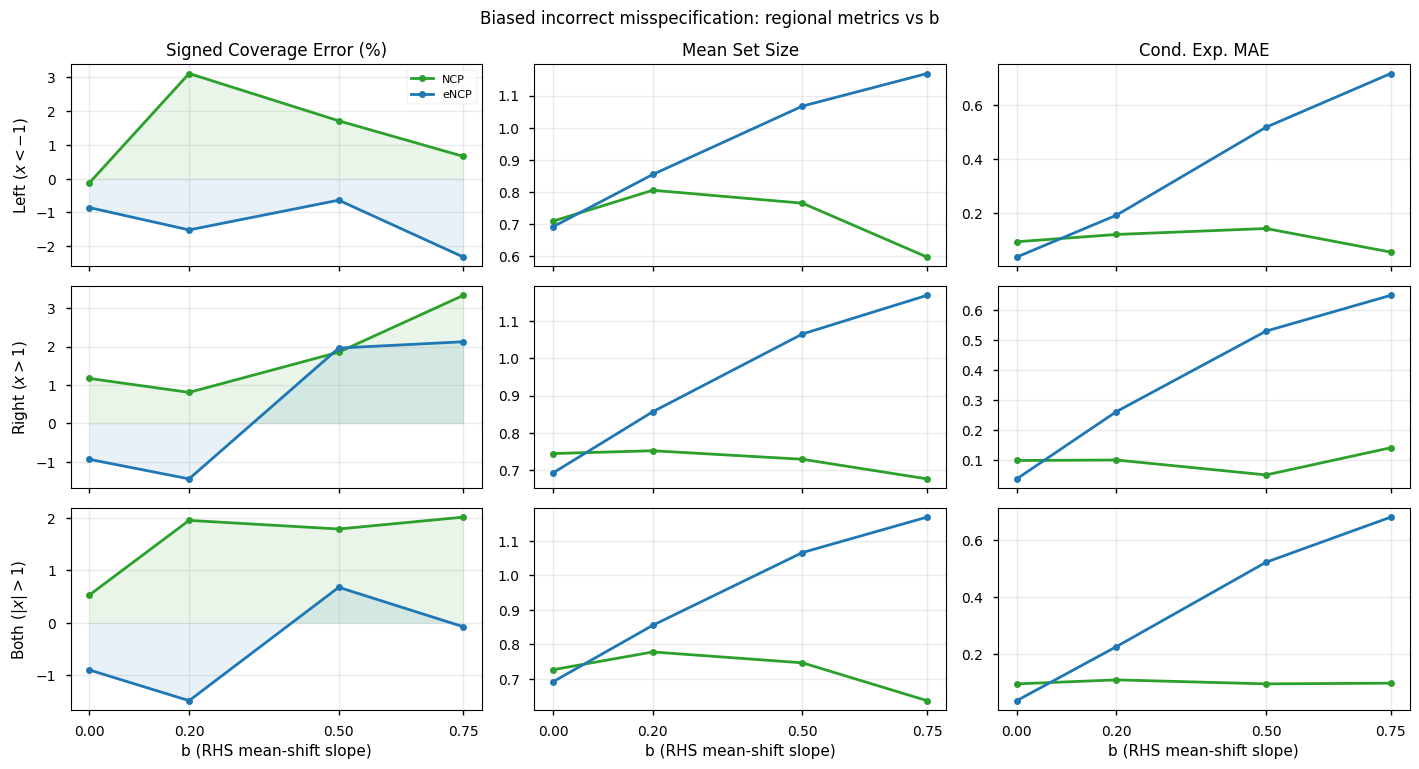

In [ ]:
if "df_b_sweep_regions" not in globals():
    df_b_sweep_regions = pd.read_csv(b_sweep_regions_csv)

plot_metrics_b = [
    ("mean_coverage_error_pct", "Signed Coverage Error (%)"),
    ("mean_set_size", "Mean Set Size"),
    ("condexp_mae", "Cond. Exp. MAE"),
]
regions_order_b = [
    ("left", r"Left ($x<-1$)"),
    ("right", r"Right ($x>1$)"),
    ("both", r"Both ($|x|>1$)"),
]
colors_b = {"NCP": "tab:green", "eNCP": "tab:blue"}

fig_bl, axs_bl = plt.subplots(3, 3, figsize=(FIG_SIZE[0] * 2.6, FIG_SIZE[1] * 2.6), sharex=True)
axs_bl = np.asarray(axs_bl)

for r_idx, (region_key, region_label) in enumerate(regions_order_b):
    for c_idx, (metric, metric_title) in enumerate(plot_metrics_b):
        ax = axs_bl[r_idx, c_idx]
        for model_name in ["NCP", "eNCP"]:
            df_rm = df_b_sweep_regions[
                (df_b_sweep_regions["region"] == region_key) & (df_b_sweep_regions["model"] == model_name)
            ].sort_values("b_rhs")
            df_x = pd.DataFrame({"b_rhs": [float(b) for b in B_SWEEP]})
            df_plot = df_x.merge(df_rm[["b_rhs", metric]], on="b_rhs", how="left")
            x_vals = df_plot["b_rhs"].to_numpy(dtype=float)
            y_vals = df_plot[metric].to_numpy(dtype=float)
            ax.plot(
                x_vals,
                y_vals,
                marker="o",
                linewidth=2.0,
                markersize=5,
                color=colors_b[model_name],
                label=model_name,
            )
            if metric == "mean_coverage_error_pct":
                mask_fin = np.isfinite(y_vals)
                ax.fill_between(
                    x_vals[mask_fin],
                    np.zeros_like(y_vals[mask_fin]),
                    y_vals[mask_fin],
                    color=colors_b[model_name],
                    alpha=0.10,
                )

        if r_idx == 0:
            ax.set_title(metric_title)
        if c_idx == 0:
            ax.set_ylabel(region_label)
        if r_idx == len(regions_order_b) - 1:
            ax.set_xlabel("b (RHS mean-shift slope)")

        ax.set_xticks([float(b) for b in B_SWEEP])
        ax.grid(True, alpha=0.25)

axs_bl[0, 0].legend(fontsize=8)
fig_bl.suptitle("Biased incorrect misspecification: regional metrics vs b")
fig_bl.tight_layout()
fig_bl.savefig(PLOT_PATH / "incorrect_conditional_biased_metrics_vs_B_regions_3x3.png", dpi=220)
plt.show()